<a href="https://colab.research.google.com/github/Josiah-Kunz/MGN-Public/blob/main/examples/colab/1_basic_tools/4_fem_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introductory example to build and run an FEM object.

In [4]:
%%capture

try:
    import google.colab  # noqa: F401
except ImportError:
    import ufl_legacy
    import fenics
else:
    try:
        import ufl_legacy
        import fenics
    except ImportError:
        !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
        import ufl_legacy
        import fenics

!apt-get install -y libglu1-mesa -q
!pip install meshgraphnet -q

from meshgraphnet import *

!wget "https://raw.githubusercontent.com/Josiah-Kunz/MGN-Public/refs/heads/colab-examples/examples/local/cantilever/geometries/cantilever.stp" -O "cantilever.stp" -q

In [7]:
%%capture --no-stderr --no-display
def main():

    # Get a mesh
    mesh = MeshObject("cantilever.stp", 250, units=Units.SI_MM, force_2d=True, convert_to=Units.SI)

    # Use a common material (or define your own)
    material = Material.steel()

    # Load it
    loads = LoadCollection(units=mesh.unit_system)
    gravity_load = material.get_gravity_load(mesh.unit_system)
    loads.add(VolumeLoad(gravity_load, name="Gravity"))
    loads.add(SurfaceLoad("top", pressure=(0, -1e5, 0), name="Applied Load"))  # N/m^2 since SI
    loads.summary()

    # Define boundary conditions
    bcs =[]
    bcs.append(FixedBoundary('left', value=(0, 0, 0), name="Fixed"))

    # Combine to form FEM object
    fem = FEMObject(
        mesh=mesh,
        loads=loads,
        boundaries=bcs,
        material=material,
        name="Cantilever beam",
    )

    # Make sure everything's okay
    fem.visualize_setup()

    # Do the math
    fem.solve()

    # Save results (probably shouldn't on Colab, though)
    #data_file = os.path.join("results", "cantilever_fem_results.csv")
    #fem.save_results(data_file)

    # Show results
    fem.plot_displacement()
    fem.plot_deformed(scale=10)
    fem.plot_stress()   # Default is von Mises
    fem.plot_stress("xx")
    fem.plot_stress("yy")
    fem.plot_stress("xy")

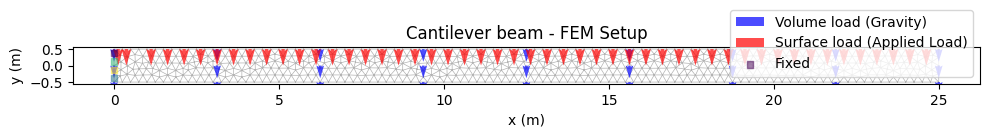

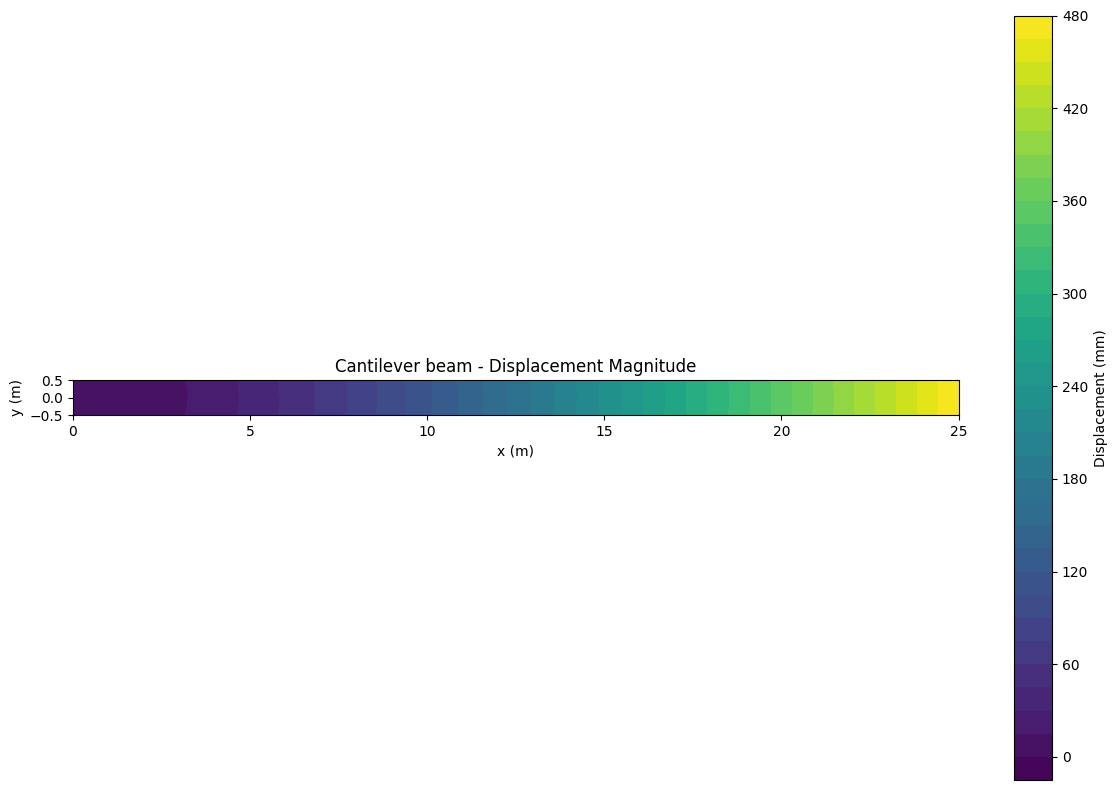

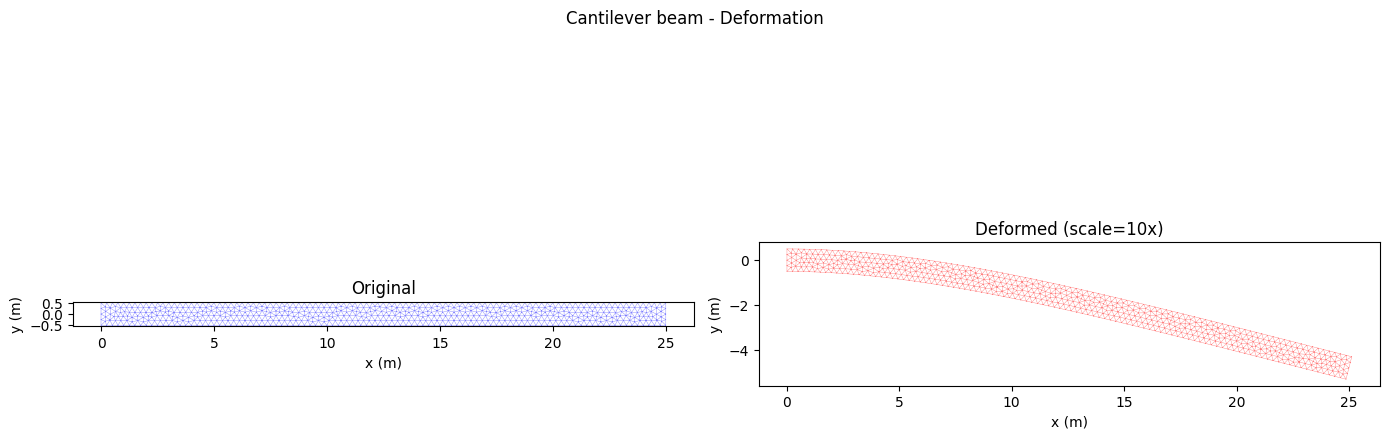

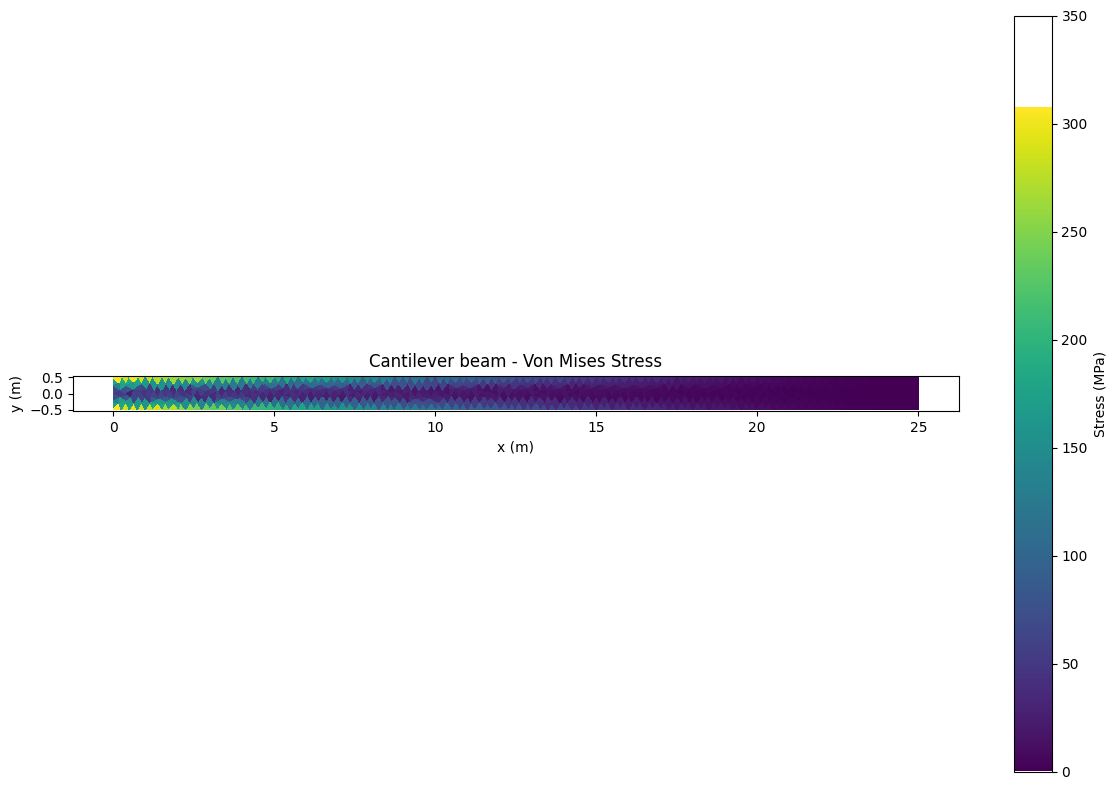

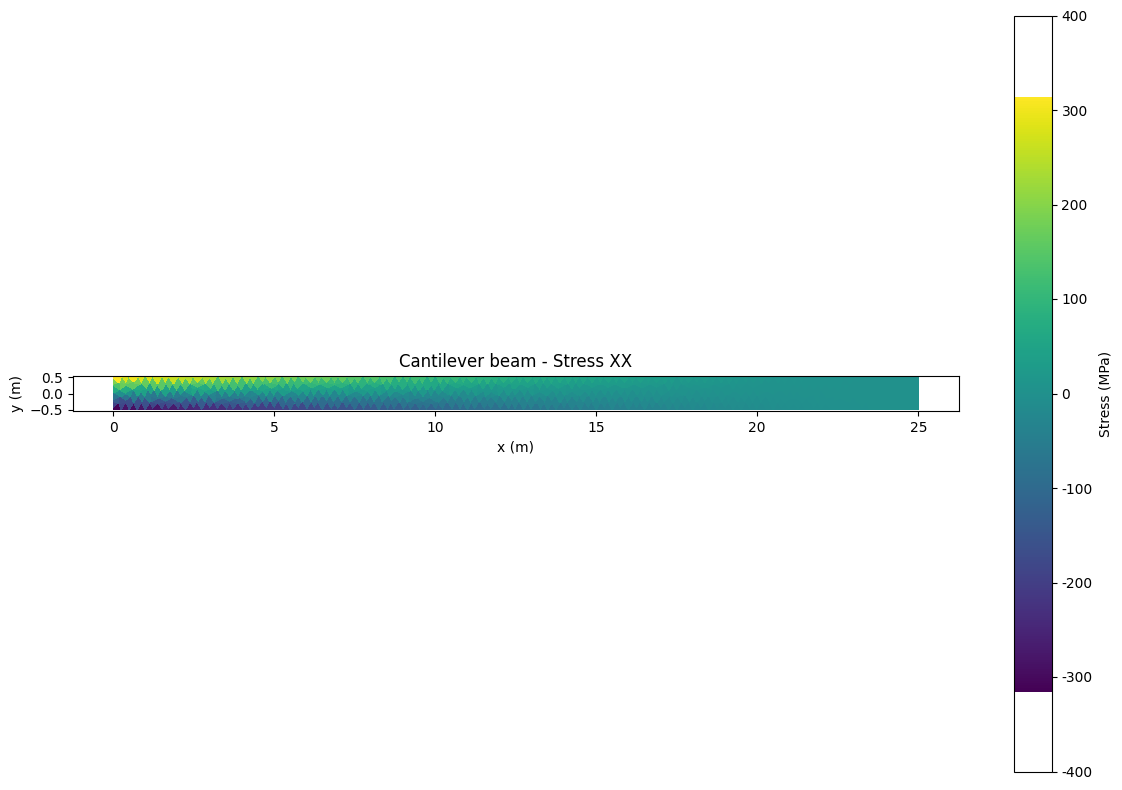

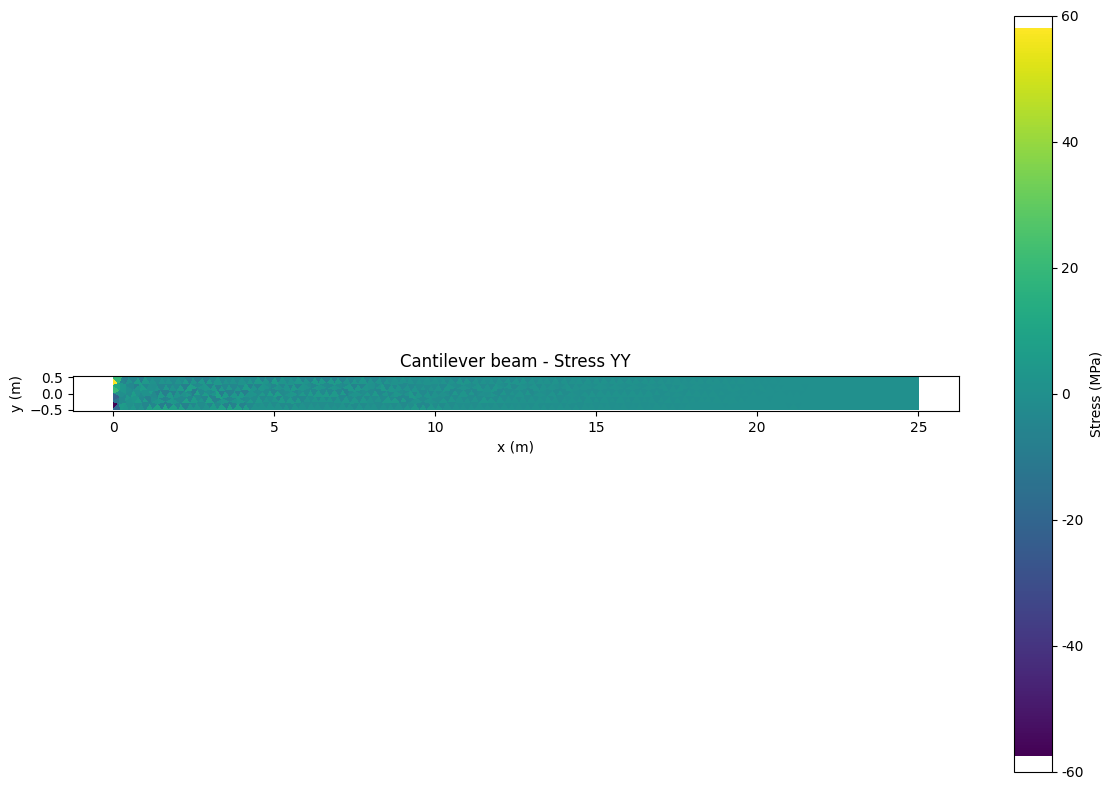

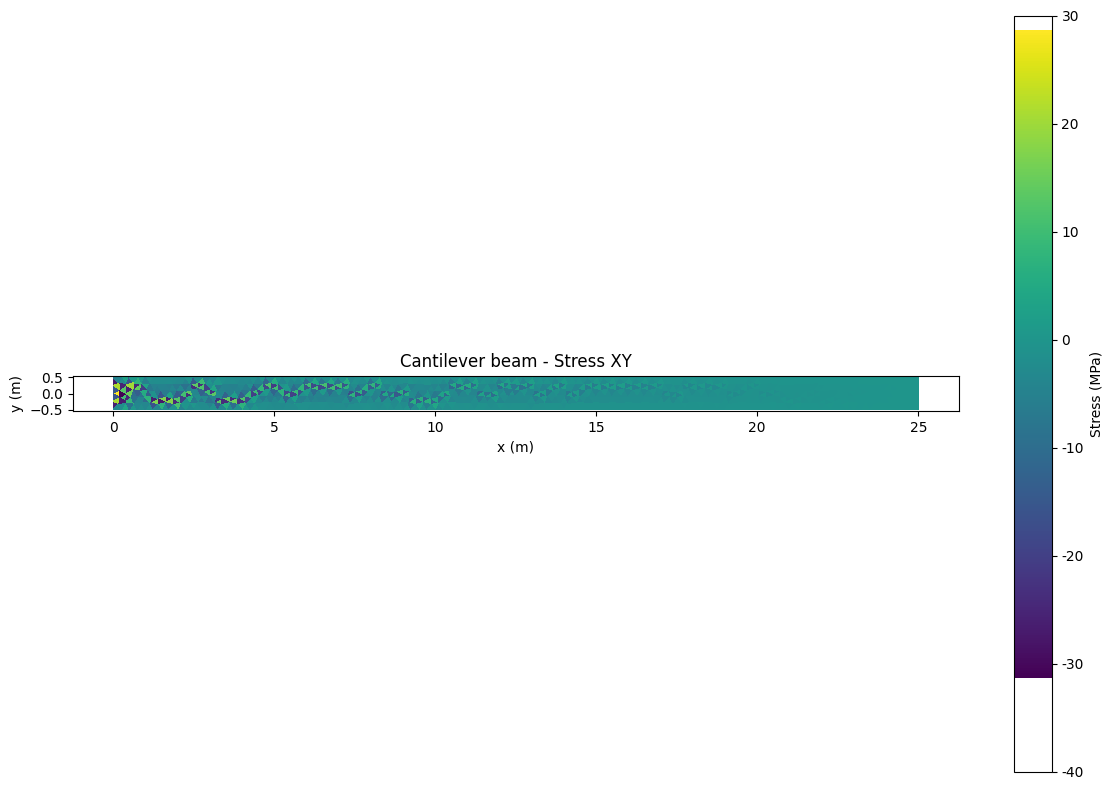

In [8]:
%%capture --no-stderr --no-display
if __name__ == "__main__":
    main()